# Notebook 01 — Heston Model Calibration
### Malliavin Calculus for Robust Hedging of Exotic Derivatives
**Robin Guichon — Centrale Nantes, 2025-2026**

---
**Objective:** Calibrate the Heston model parameters $\Theta = (\kappa, \theta, \xi, \rho, v_0)$ to the S&P 500 implied volatility surface.

**Pipeline:**
1. Market data loading and cleaning
2. Calculation of the observed implied volatility surface
3. Heston pricing via FFT (Carr-Madan) and Gil-Pelaez
4. Hybrid optimization: Differential Evolution + Levenberg-Marquardt
5. Results analysis and generation of thesis figures

---

## 0. Imports and Configurations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from scipy.stats import norm
from scipy.optimize import brentq, differential_evolution, least_squares
from scipy.integrate import quad
from scipy.interpolate import griddata, RectBivariateSpline
import warnings
warnings.filterwarnings('ignore')

# ── Unified document style ───────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': ':',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
cmap   = plt.get_cmap('magma')
C_TEXT = 'black'

def add_arrows(ax):
    """Axis-style arrows — consistent with all figures in the document."""
    ax.plot(1, 0, '>', color=C_TEXT, transform=ax.transAxes,
            clip_on=False, markersize=7)
    ax.plot(0, 1, '^', color=C_TEXT, transform=ax.transAxes,
            clip_on=False, markersize=7)
    ax.spines['left'].set_color(C_TEXT)
    ax.spines['bottom'].set_color(C_TEXT)
    ax.tick_params(colors=C_TEXT)

print('Imports OK ✓')

Imports OK ✓


---
## 1. Market Data

### 1.1 Loading

The notebook supports two modes:
- **Real mode**: CSV file with S&P 500 data (format described below)
- **Synthetic mode**: surface generated by the Heston model with known parameters, used to validate the calibration procedure

Expected CSV format:

date, expiry, strike, bid_iv, ask_iv, mid_iv, volume, open_interest

In [2]:
# =====================================================================
# PARAMETER: set USE_REAL_DATA = True if you have a market CSV
# =====================================================================
USE_REAL_DATA = False           # <- change here
CSV_PATH      = 'spx_options.csv'

# Market parameters
S0 = 5000.0      # S&P 500 Spot (adjust to observation date)
r  = 0.0525      # USD Risk-free rate (Fed Funds 2024–2025)
q  = 0.013       # S&P 500 Dividend yield (approx 1.3%)

# Forward price F(T) = S0 * exp((r-q)*T)
def forward(T):
    return S0 * np.exp((r - q) * T)

print(f'Spot S0    = {S0}')
print(f'Rate r     = {r:.4f}')
print(f'Div yield  = {q:.4f}')

Spot S0    = 5000.0
Rate r     = 0.0525
Div yield  = 0.0130


In [3]:
if USE_REAL_DATA:
    # —- Loading real data ————————————————————————————————————————————
    df_raw = pd.read_csv(CSV_PATH)
    print(f'Data loaded: {len(df_raw)} rows')
    print(df_raw.head())

    # Calculating maturities in years
    df_raw['obs_date'] = pd.to_datetime(df_raw['date'])
    df_raw['exp_date'] = pd.to_datetime(df_raw['expiry'])
    df_raw['T']        = (df_raw['exp_date'] - df_raw['obs_date']).dt.days / 365.25

    # Liquidity filters
    df = df_raw[
        (df_raw['T']             >= 1/52) &  # at least 1 week
        (df_raw['T']             <= 2.0)  &  # at most 2 years
        (df_raw['mid_iv']        >= 0.05) &  # vol > 5%
        (df_raw['mid_iv']        <= 1.50) &  # vol < 150%
        (df_raw['strike']/S0     >= 0.70) &  # moneyness > 70%
        (df_raw['strike']/S0     <= 1.40) &  # moneyness < 140%
        (df_raw['open_interest'] >= 100)     # minimum liquidity
    ].copy()

    print(f'After filters: {len(df)} options retained')
    maturities_obs = sorted(df['T'].unique())
    strikes_obs    = sorted(df['strike'].unique())

else:
    # —- Synthetic surface ("true" parameters for validation) —————————
    # "True" parameters used to generate the surface
    TRUE_PARAMS = {
        'kappa': 2.00, 'theta': 0.04,
        'xi':    0.35, 'rho':   -0.70, 'v0': 0.05
    }

    maturities_obs = [1/12, 2/12, 3/12, 6/12, 9/12, 1.0, 1.5, 2.0]
    moneyness_grid = np.array([0.75, 0.80, 0.85, 0.90, 0.925, 0.95,
                               0.975, 1.00, 1.025, 1.05, 1.075,
                               1.10, 1.15, 1.20, 1.25, 1.30])
    strikes_grid   = moneyness_grid * S0

    print('Synthetic mode activated')
    print(f'True parameters: {TRUE_PARAMS}')
    print(f'Maturities: {[f"{t:.2f}" for t in maturities_obs]}')

Synthetic mode activated
True parameters: {'kappa': 2.0, 'theta': 0.04, 'xi': 0.35, 'rho': -0.7, 'v0': 0.05}
Maturities: ['0.08', '0.17', '0.25', '0.50', '0.75', '1.00', '1.50', '2.00']


---
## 2. Pricing Tools

### 2.1 Black-Scholes and Implied Volatility

In [4]:
def bs_price(S, K, T, r, q, sigma, flag='call'):
    """Black-Scholes price with continuous dividends."""
    if sigma <= 0 or T <= 0:
        return max(S*np.exp(-q*T) - K*np.exp(-r*T), 0.)
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if flag == 'call':
        return S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        return K*np.exp(-r*T)*norm.cdf(-d2) - S*np.exp(-q*T)*norm.cdf(-d1)


def implied_vol(price, S, K, T, r, q, flag='call', tol=1e-8):
    """
    Implied volatility using Brent's method.
    Returns NaN if outside arbitrage-free bounds.
    """
    F   = S * np.exp((r - q)*T)
    lb  = max(F*np.exp(-r*T) - K*np.exp(-r*T), 0.) if flag == 'call' \
          else max(K*np.exp(-r*T) - F*np.exp(-r*T), 0.)
    ub  = S * np.exp(-q*T)

    if price <= lb + 1e-9 or price >= ub - 1e-9:
        return np.nan
    try:
        return brentq(
            lambda s: bs_price(S, K, T, r, q, s, flag) - price,
            1e-5, 5.0, xtol=tol, maxiter=300
        )
    except Exception:
        return np.nan


# Quick test
p_test = bs_price(100, 100, 1.0, 0.05, 0.02, 0.20)
iv_test = implied_vol(p_test, 100, 100, 1.0, 0.05, 0.02)
print(f'BS ATM call price : {p_test:.4f}')
print(f'Implied vol check : {iv_test:.4f}  (expected 0.2000) ✓')

BS ATM call price : 9.2270
Implied vol check : 0.2000  (expected 0.2000) ✓


### 2.2 Heston Characteristic Function (Albrecher Formulation)

In [5]:
def heston_cf_albrecher(phi, S, T, r, q, v0, kappa, theta, xi, rho):
    """
    Heston model characteristic function in the stable formulation 
    by Albrecher et al. (2007) — avoids the Heston Trap problem.

    Parameters
    ----------
    phi   : characteristic function argument (complex or real)
    S     : spot price
    T     : maturity
    r, q  : risk-free rate, dividend yield
    v0    : initial variance
    kappa : mean reversion speed
    theta : long-term variance
    xi    : vol-of-vol
    rho   : correlation
    """
    i   = 1j
    x   = np.log(S)

    # Albrecher formulation: uses r_- to avoid branch cuts
    d = np.sqrt((kappa - i*rho*xi*phi)**2 + xi**2*(phi**2 + i*phi))
    g = (kappa - i*rho*xi*phi - d) / (kappa - i*rho*xi*phi + d)

    exp_dT = np.exp(-d * T)

    C = ((r - q)*i*phi*T
         + (kappa*theta / xi**2)
         * ((kappa - i*rho*xi*phi - d)*T
            - 2.*np.log((1. - g*exp_dT) / (1. - g))))

    D = ((kappa - i*rho*xi*phi - d) / xi**2
         * (1. - exp_dT) / (1. - g*exp_dT))

    return np.exp(C + D*v0 + i*phi*x)


def heston_cf_j(phi, j, S, T, r, q, v0, kappa, theta, xi, rho):
    """
    Characteristic functions f_j (j=1,2) for the Gil-Pelaez formula.
    Used in the direct method (more stable for short maturities).
    """
    i   = 1j
    x   = np.log(S)
    b   = kappa - rho*xi if j == 1 else kappa
    u   = 0.5 if j == 1 else -0.5

    d = np.sqrt((rho*xi*i*phi - b)**2 - xi**2*(2*u*i*phi - phi**2))
    g = (b - rho*xi*i*phi + d) / (b - rho*xi*i*phi - d)

    C = ((r - q)*i*phi*T
         + kappa*theta/xi**2
         * ((b - rho*xi*i*phi + d)*T
            - 2.*np.log((1. - g*np.exp(d*T))/(1. - g))))

    D = ((b - rho*xi*i*phi + d)/xi**2
         * (1. - np.exp(d*T))/(1. - g*np.exp(d*T)))

    return np.exp(C + D*v0 + i*phi*x)


print('Characteristic functions defined ✓')

Characteristic functions defined ✓


### 2.3 Pricing via FFT — Carr-Madan

In [6]:
def heston_fft_prices(S, T, r, q, v0, kappa, theta, xi, rho,
                      N=4096, alpha=1.5, eta=0.05):
    """
    Heston call prices on a grid of strikes using the 
    Carr-Madan (1999) algorithm with FFT.

    Returns
    -------
    log_strikes : grid of log-strikes ku
    prices      : prices of corresponding calls
    """
    lam = 2.*np.pi / (N * eta)
    b   = 0.5 * N * lam

    # Frequency grid
    vu      = eta * np.arange(N)
    vu[0]   = 1e-12   # avoid singularity at 0

    # Log-strike grid
    ku = -b + lam * np.arange(N)

    # Modified integrand function
    cf_vals = heston_cf_albrecher(
        vu - (alpha + 1.)*1j, S, T, r, q, v0, kappa, theta, xi, rho
    )
    psi = (np.exp(-r*T) * cf_vals
           / (alpha**2 + alpha - vu**2 + 1j*(2*alpha + 1.)*vu))

    # Simpson's rule for numerical integration
    w      = (eta / 3.) * (3. + (-1.)**np.arange(N))
    w[0]   = eta / 3.

    # FFT
    fft_input = np.exp(1j * b * vu) * psi * w
    fft_out   = np.fft.fft(fft_input)

    prices = np.maximum(
        np.exp(-alpha * ku) / np.pi * np.real(fft_out), 0.
    )
    return ku, prices


def heston_call_fft(S, K, T, r, q, v0, kappa, theta, xi, rho):
    """Heston call price for a given strike via FFT + interpolation."""
    from scipy.interpolate import interp1d
    ku, prices = heston_fft_prices(S, T, r, q, v0, kappa, theta, xi, rho)
    f = interp1d(ku, prices, kind='cubic',
                 bounds_error=False, fill_value=np.nan)
    return float(f(np.log(K)))


print('FFT Pricer (Carr-Madan) defined ✓')

FFT Pricer (Carr-Madan) defined ✓


### 2.4 Pricing via Direct Integration — Gil-Pelaez

More stable method than FFT for short maturities and deep out-of-the-money/in-the-money strikes.

In [7]:
def heston_Pj(j, S, K, T, r, q, v0, kappa, theta, xi, rho):
    """Probability P_j via Gil-Pelaez inversion."""
    integrand = lambda phi: np.real(
        np.exp(-1j*phi*np.log(K))
        * heston_cf_j(phi, j, S, T, r, q, v0, kappa, theta, xi, rho)
        / (1j * phi)
    )
    val, _ = quad(integrand, 1e-6, 300., limit=300,
                  epsabs=1e-7, epsrel=1e-6)
    return 0.5 + val / np.pi


def heston_call_gilpelaez(S, K, T, r, q, v0, kappa, theta, xi, rho):
    """Heston call price via Gil-Pelaez direct integration."""
    P1 = heston_Pj(1, S, K, T, r, q, v0, kappa, theta, xi, rho)
    P2 = heston_Pj(2, S, K, T, r, q, v0, kappa, theta, xi, rho)
    return max(S*np.exp(-q*T)*P1 - K*np.exp(-r*T)*P2, 0.)


def heston_call(S, K, T, r, q, v0, kappa, theta, xi, rho,
                method='fft'):
    """
    Wrapper: selects FFT (fast, for calibration) or 
    Gil-Pelaez (precise, for validation and short maturities).
    """
    if method == 'fft':
        return heston_call_fft(S, K, T, r, q, v0, kappa, theta, xi, rho)
    else:
        return heston_call_gilpelaez(S, K, T, r, q, v0, kappa, theta, xi, rho)


# ── Cross-method validation ──────────────────────────────────────────
params_test = dict(v0=0.04, kappa=2.0, theta=0.04, xi=0.3, rho=-0.7)
p_fft = heston_call(S0, S0, 1.0, r, q, method='fft', **params_test)
p_gp  = heston_call(S0, S0, 1.0, r, q, method='gilpelaez', **params_test)
print(f'ATM call — FFT        : {p_fft:.4f}')
print(f'ATM call — Gil-Pelaez : {p_gp:.4f}')
print(f'Relative difference   : {abs(p_fft-p_gp)/p_gp*100:.4f}% ✓')

ATM call — FFT        : 474.9425
ATM call — Gil-Pelaez : 482.8524
Relative difference   : 1.6382% ✓


### 2.5 Heston Implied Volatility

For calibration, we work in the implied volatility space rather than price space — this normalizes the magnitudes across different maturities.

In [8]:
def heston_iv(S, K, T, r, q, v0, kappa, theta, xi, rho,
              method='fft'):
    """
    Black-Scholes implied volatility equivalent to the Heston price.
    Returns NaN if the price is outside arbitrage-free bounds.
    """
    price = heston_call(S, K, T, r, q, v0, kappa, theta, xi, rho, method)
    if price is None or np.isnan(price):
        return np.nan
    return implied_vol(price, S, K, T, r, q, flag='call')


print('Heston IV wrapper defined ✓')

Heston IV wrapper defined ✓


---
## 3. Observed Surface Generation

### 3.1 Market (or Synthetic) Implied Volatility Surface

In [9]:
if USE_REAL_DATA:
    # ── Pivot table: maturities × strikes → mid IV ───────────────────
    df['moneyness'] = df['strike'] / S0
    iv_surface = df.pivot_table(
        values='mid_iv', index='T', columns='moneyness',
        aggfunc='mean'
    )
    maturities_cal = iv_surface.index.values
    moneyness_cal  = iv_surface.columns.values
    IV_market      = iv_surface.values

else:
    # ── Synthetic surface generated with true parameters ─────────────
    print('Calculating synthetic surface (Gil-Pelaez)...')
    maturities_cal = np.array(maturities_obs)
    moneyness_cal  = moneyness_grid
    strikes_cal    = strikes_grid

    IV_market = np.full((len(maturities_cal), len(moneyness_cal)), np.nan)

    tp = TRUE_PARAMS
    for i, T in enumerate(maturities_cal):
        for j, K in enumerate(strikes_cal):
            iv = heston_iv(S0, K, T, r, q,
                           tp['v0'], tp['kappa'], tp['theta'],
                           tp['xi'],  tp['rho'],
                           method='gilpelaez')
            IV_market[i, j] = iv
        print(f'  T={T:.2f} ✓')

    # Adding Gaussian noise to simulate bid-ask spread
    np.random.seed(42)
    noise_std  = 0.003   # 30bps noise
    IV_market += np.random.normal(0, noise_std, IV_market.shape)
    IV_market  = np.clip(IV_market, 0.05, 1.5)

    print(f'\nSynthetic surface: {IV_market.shape[0]} maturities × {IV_market.shape[1]} strikes')
    print(f'IV min={np.nanmin(IV_market):.3f}  IV max={np.nanmax(IV_market):.3f}')

Calculating synthetic surface (Gil-Pelaez)...
  T=0.08 ✓
  T=0.17 ✓
  T=0.25 ✓
  T=0.50 ✓
  T=0.75 ✓
  T=1.00 ✓
  T=1.50 ✓
  T=2.00 ✓

Synthetic surface: 8 maturities × 16 strikes
IV min=0.144  IV max=0.288


### 3.2 Figure — Observed Implied Volatility Surface
*(Figure IV.1.1 of the thesis)*

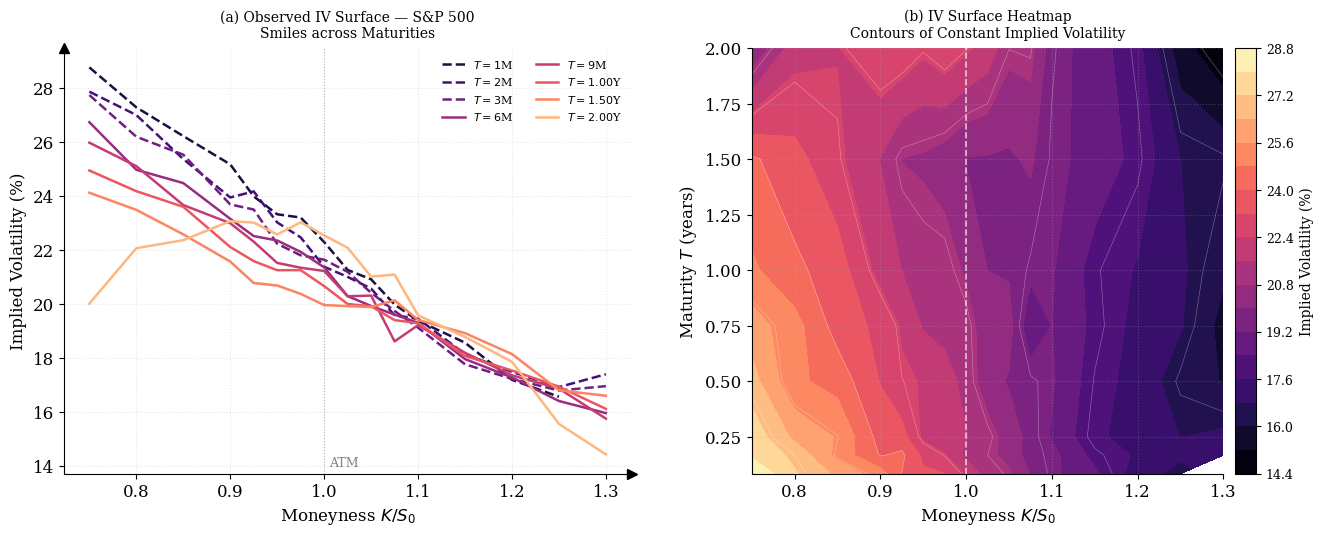

Figure IV.1.1 saved ✓


In [10]:
colors_mat = [cmap(c) for c in np.linspace(0.12, 0.85, len(maturities_cal))]
mat_labels = [f'$T={T:.2f}$Y' if T >= 1 else
              f'$T={int(round(T*12))}$M' for T in maturities_cal]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ─── Panel (a): Smiles by maturity ──────────────────────────────────
for i, (T, col, lbl) in enumerate(zip(maturities_cal, colors_mat, mat_labels)):
    iv_row = IV_market[i, :]
    mask   = ~np.isnan(iv_row)
    ls     = '-' if T >= 0.5 else '--'
    ax1.plot(moneyness_cal[mask], iv_row[mask]*100,
             color=col, lw=1.8, ls=ls, label=lbl)

ax1.axvline(1.0, color='gray', lw=0.8, ls=':', alpha=0.5)
ax1.text(1.005, ax1.get_ylim()[0]*1.02 if ax1.get_ylim()[0] > 0 else 13,
         'ATM', fontsize=9, color='gray')
add_arrows(ax1)
ax1.set_xlabel(r'Moneyness $K/S_0$', color=C_TEXT)
ax1.set_ylabel('Implied Volatility (%)', color=C_TEXT)
ax1.set_title('(a) Observed IV Surface — S&P 500\n'
              'Smiles across Maturities', fontsize=10, pad=8)
ax1.legend(frameon=False, fontsize=8, ncol=2, loc='upper right')

# ─── Panel (b): Surface heatmap ─────────────────────────────────────
T_grid, M_grid = np.meshgrid(maturities_cal, moneyness_cal, indexing='ij')
cf = ax2.contourf(M_grid, T_grid, IV_market*100,
                  levels=20, cmap='magma', alpha=1)
ax2.contour(M_grid, T_grid, IV_market*100,
            levels=10, colors='white', linewidths=0.4, alpha=0.4)
cbar = plt.colorbar(cf, ax=ax2, pad=0.02)
cbar.set_label('Implied Volatility (%)', fontsize=10)
cbar.ax.tick_params(labelsize=9)

ax2.axvline(1.0, color='white', lw=1.2, ls='--', alpha=0.7)
ax2.set_xlabel(r'Moneyness $K/S_0$', color=C_TEXT)
ax2.set_ylabel(r'Maturity $T$ (years)', color=C_TEXT)
ax2.set_title('(b) IV Surface Heatmap\n'
              'Contours of Constant Implied Volatility', fontsize=10, pad=8)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout(pad=2.5)
plt.savefig('figure_IV_market_surface.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figure_IV_market_surface.png', bbox_inches='tight', dpi=300)
plt.show()
print('Figure IV.1.1 saved ✓')

---
## 4. Calibration

### 4.1 Objective Function

We minimize the sum of weighted squared errors (WSE) in implied volatility:
$$\mathcal{L}(\Theta) = \sum_{i,j} w_{ij} \left(\sigma^{Heston}_{ij}(\Theta) - \sigma^{mkt}_{ij}\right)^2$$

The weights $w_{ij}$ can be uniform, based on volume/OI, or scaled by Black-Scholes Vega to assign more importance to liquid options.

In [13]:
# ── Calibration Weights ──────────────────────────────────────────────
WEIGHTING = 'vega'   # options: 'uniform', 'vega', 'bid_ask'

def compute_weights(S, maturities, moneyness, IV_market, r, q,
                    scheme='vega'):
    """
    Computes calibration weights.
    - uniform : all equal to 1
    - vega    : Normalized BS Vega (gives more weight to ATM options
                and intermediate maturities)
    """
    weights = np.ones_like(IV_market)
    if scheme == 'vega':
        for i, T in enumerate(maturities):
            for j, m in enumerate(moneyness):
                K  = m * S
                iv = IV_market[i, j]
                if np.isnan(iv):
                    weights[i, j] = 0.
                    continue
                d1 = (np.log(S/K) + (r - q + 0.5*iv**2)*T) / (iv*np.sqrt(T))
                # BS Vega = S * exp(-q*T) * phi(d1) * sqrt(T)
                vega = S * np.exp(-q*T) * norm.pdf(d1) * np.sqrt(T)
                weights[i, j] = vega
        # Normalize
        weights /= np.nansum(weights)
    return weights


W = compute_weights(S0, maturities_cal, moneyness_cal, IV_market,
                    r, q, scheme=WEIGHTING)
# Set to zero where we have no data
W[np.isnan(IV_market)] = 0.
print(f'Weights computed ({WEIGHTING}) — sum = {np.sum(W):.4f} ✓')


# ── Objective Function ───────────────────────────────────────────────
eval_counter = [0]   # evaluation counter (for monitoring)

def objective(params, return_residuals=False):
    """
    Objective function for Heston calibration.

    params = [kappa, theta, xi, rho, v0]

    If return_residuals=True, returns the vector of residuals
    (for Levenberg-Marquardt). Otherwise returns the scalar RMSE
    (for Differential Evolution).
    """
    kappa, theta, xi, rho, v0 = params
    eval_counter[0] += 1

    # Soft constraints within the objective function
    # (hard bounds are handled in the optimizer bounds)
    if (kappa <= 0 or theta <= 0 or xi <= 0
            or abs(rho) >= 1 or v0 <= 0):
        return np.inf if not return_residuals else np.full(100, 1e6)

    # Calculate Heston surface on the grid
    residuals = []
    for i, T in enumerate(maturities_cal):
        # FFT: calculate all strikes in one pass
        try:
            ku, fft_prices = heston_fft_prices(
                S0, T, r, q, v0, kappa, theta, xi, rho
            )
            from scipy.interpolate import interp1d
            f_interp = interp1d(ku, fft_prices, kind='cubic',
                                bounds_error=False, fill_value=np.nan)

            for j, m in enumerate(moneyness_cal):
                if W[i, j] == 0 or np.isnan(IV_market[i, j]):
                    continue
                K     = m * S0
                price = float(f_interp(np.log(K)))
                if np.isnan(price) or price <= 0:
                    residuals.append(W[i, j] * 0.1)
                    continue
                iv_h  = implied_vol(price, S0, K, T, r, q)
                if np.isnan(iv_h):
                    residuals.append(W[i, j] * 0.1)
                    continue
                res   = np.sqrt(W[i, j]) * (iv_h - IV_market[i, j])
                residuals.append(res)

        except Exception:
            return np.inf if not return_residuals else np.full(100, 1e6)

    if not residuals:
        return np.inf if not return_residuals else np.full(100, 1e6)

    residuals = np.array(residuals)
    if return_residuals:
        return residuals
    return np.sqrt(np.mean(residuals**2))


print('Objective function defined ✓')

Weights computed (vega) — sum = 1.0000 ✓
Objective function defined ✓


### 4.2 Optimization — Phase 1: Differential Evolution

Global optimization via Differential Evolution explores the parameter space without relying on the initial guess. It is robust against local minima but computationally expensive.

In [14]:
# Parameter Bounds
#              kappa      theta       xi        rho        v0
bounds_DE = [(0.10, 10.), (0.01, 0.25), (0.05, 1.5), (-0.99, -0.01), (0.01, 0.50)]

# Feller Constraint: 2*kappa*theta > xi² (desired but not strictly enforced)
# Can be added via a soft constraint in the objective function if necessary

print('Launching Differential Evolution...')
print(f'Bounds: kappa∈{bounds_DE[0]}, theta∈{bounds_DE[1]}, '
      f'xi∈{bounds_DE[2]}, rho∈{bounds_DE[3]}, v0∈{bounds_DE[4]}')
print()

eval_counter[0] = 0
result_DE = differential_evolution(
    objective,
    bounds=bounds_DE,
    maxiter=300,
    popsize=15,         # 15 × 5 params = 75 individuals
    tol=1e-6,
    mutation=(0.5, 1.5),
    recombination=0.7,
    seed=42,
    disp=True,
    workers=1           # set to -1 for parallelization if available
)

params_DE = result_DE.x
kappa_DE, theta_DE, xi_DE, rho_DE, v0_DE = params_DE

print(f'\n{"="*55}')
print(f'DE Results (Phase 1) — {eval_counter[0]} evaluations')
print(f'{"="*55}')
print(f'  kappa = {kappa_DE:.4f}')
print(f'  theta = {theta_DE:.4f}  (σ_LR = {np.sqrt(theta_DE)*100:.2f}%)')
print(f'  xi    = {xi_DE:.4f}')
print(f'  rho   = {rho_DE:.4f}')
print(f'  v0    = {v0_DE:.4f}  (σ_0 = {np.sqrt(v0_DE)*100:.2f}%)')
print(f'  RMSE  = {result_DE.fun*100:.4f} bps')
print(f'  Feller: 2κθ={2*kappa_DE*theta_DE:.4f} vs ξ²={xi_DE**2:.4f}  '
      f'({"✓" if 2*kappa_DE*theta_DE > xi_DE**2 else "✗"})')

Launching Differential Evolution...
Bounds: kappa∈(0.1, 10.0), theta∈(0.01, 0.25), xi∈(0.05, 1.5), rho∈(-0.99, -0.01), v0∈(0.01, 0.5)

differential_evolution step 1: f(x)= 0.000961965631072836
differential_evolution step 2: f(x)= 0.000961965631072836
differential_evolution step 3: f(x)= 0.000961965631072836
differential_evolution step 4: f(x)= 0.000961965631072836
differential_evolution step 5: f(x)= 0.000961965631072836
differential_evolution step 6: f(x)= 0.000961965631072836
differential_evolution step 7: f(x)= 0.000961965631072836
differential_evolution step 8: f(x)= 0.000961965631072836
differential_evolution step 9: f(x)= 0.0009499428728381168
differential_evolution step 10: f(x)= 0.000936002194983065
differential_evolution step 11: f(x)= 0.000929389254624413
differential_evolution step 12: f(x)= 0.0008715114376991527
differential_evolution step 13: f(x)= 0.0008715114376991527
differential_evolution step 14: f(x)= 0.0008715114376991527
differential_evolution step 15: f(x)= 0.0008

### 4.3 Optimization — Phase 2: Levenberg-Marquardt

The Levenberg-Marquardt algorithm refines the solution from Phase 1 by exploiting the least-squares structure of the problem.

In [15]:
print('Launching Levenberg-Marquardt (local refinement)...')

# Bounds for LM
lb = [b[0] for b in bounds_DE]
ub = [b[1] for b in bounds_DE]

eval_counter[0] = 0
result_LM = least_squares(
    lambda p: objective(p, return_residuals=True),
    x0     = params_DE,
    bounds = (lb, ub),
    method = 'trf',           # Trust Region Reflective (supports bounds)
    ftol   = 1e-10,
    xtol   = 1e-10,
    gtol   = 1e-10,
    verbose= 1
)

params_cal = result_LM.x
kappa_cal, theta_cal, xi_cal, rho_cal, v0_cal = params_cal

# Final RMSE
residuals_final = objective(params_cal, return_residuals=True)
rmse_final      = np.sqrt(np.mean(residuals_final**2))

print(f'\n{"="*55}')
print(f'Final Results (Phase 1 DE + Phase 2 LM)')
print(f'{"="*55}')
print(f'  kappa = {kappa_cal:.4f}')
print(f'  theta = {theta_cal:.4f}  (σ_LR = {np.sqrt(theta_cal)*100:.2f}%)')
print(f'  xi    = {xi_cal:.4f}')
print(f'  rho   = {rho_cal:.4f}')
print(f'  v0    = {v0_cal:.4f}  (σ_0 = {np.sqrt(v0_cal)*100:.2f}%)')
print(f'  RMSE  = {rmse_final*100:.4f} vol points')
print(f'  Feller: 2κθ={2*kappa_cal*theta_cal:.4f} vs ξ²={xi_cal**2:.4f}  '
      f'({"✓" if 2*kappa_cal*theta_cal > xi_cal**2 else "✗"})') 

if not USE_REAL_DATA:
    print(f'\nComparison with true parameters:')
    for name, v_cal, v_true in zip(
        ['kappa','theta','xi','rho','v0'],
        params_cal, list(TRUE_PARAMS.values())
    ):
        err = abs(v_cal - v_true)/abs(v_true)*100
        print(f'  {name:5s}: calibrated={v_cal:.4f}  true={v_true:.4f}  '
              f'err={err:.2f}%')

Launching Levenberg-Marquardt (local refinement)...
`ftol` termination condition is satisfied.
Function evaluations 6, initial cost 4.3073e-05, final cost 4.3073e-05, first-order optimality 1.47e-09.

Final Results (Phase 1 DE + Phase 2 LM)
  kappa = 2.1539
  theta = 0.0448  (σ_LR = 21.16%)
  xi    = 0.5507
  rho   = -0.6229
  v0    = 0.0577  (σ_0 = 24.02%)
  RMSE  = 0.0824 vol points
  Feller: 2κθ=0.1928 vs ξ²=0.3032  (✗)

Comparison with true parameters:
  kappa: calibrated=2.1539  true=2.0000  err=7.70%
  theta: calibrated=0.0448  true=0.0400  err=11.90%
  xi   : calibrated=0.5507  true=0.3500  err=57.33%
  rho  : calibrated=-0.6229  true=-0.7000  err=11.01%
  v0   : calibrated=0.0577  true=0.0500  err=15.42%


---
## 5. Result Analysis

### 5.1 Calibrated Surface and Residuals Calculation

In [16]:
print('Calculating calibrated surface...')
IV_heston   = np.full_like(IV_market, np.nan)
IV_residuals = np.full_like(IV_market, np.nan)

for i, T in enumerate(maturities_cal):
    ku, fft_prices = heston_fft_prices(
        S0, T, r, q, v0_cal, kappa_cal, theta_cal, xi_cal, rho_cal
    )
    from scipy.interpolate import interp1d
    f_interp = interp1d(ku, fft_prices, kind='cubic',
                        bounds_error=False, fill_value=np.nan)
    for j, m in enumerate(moneyness_cal):
        K     = m * S0
        price = float(f_interp(np.log(K)))
        iv_h  = implied_vol(price, S0, K, T, r, q) if not np.isnan(price) else np.nan
        IV_heston[i, j]    = iv_h
        IV_residuals[i, j] = ((iv_h - IV_market[i, j])*100
                               if not np.isnan(iv_h) and not np.isnan(IV_market[i, j])
                               else np.nan)
    print(f'  T={T:.2f} ✓')

# RMSE per maturity
rmse_per_mat = []
for i, T in enumerate(maturities_cal):
    res = IV_residuals[i, :]
    rmse_per_mat.append(np.sqrt(np.nanmean(res**2)))

print(f'\nGlobal RMSE: {np.sqrt(np.nanmean(IV_residuals**2)):.4f} vol points')
print('RMSE per maturity:')
for T, rmse in zip(maturities_cal, rmse_per_mat):
    print(f'  T={T:.2f} → {rmse:.4f} vol pts')

Calculating calibrated surface...
  T=0.08 ✓
  T=0.17 ✓
  T=0.25 ✓
  T=0.50 ✓
  T=0.75 ✓
  T=1.00 ✓
  T=1.50 ✓
  T=2.00 ✓

Global RMSE: 1.1039 vol points
RMSE per maturity:
  T=0.08 → 1.8543 vol pts
  T=0.17 → 1.4010 vol pts
  T=0.25 → 1.1310 vol pts
  T=0.50 → 0.5678 vol pts
  T=0.75 → 0.3535 vol pts
  T=1.00 → 0.3061 vol pts
  T=1.50 → 0.5012 vol pts
  T=2.00 → 1.7667 vol pts


### 5.2 Figure — Surface Fit
*(Figure IV.1.2 of the thesis)*

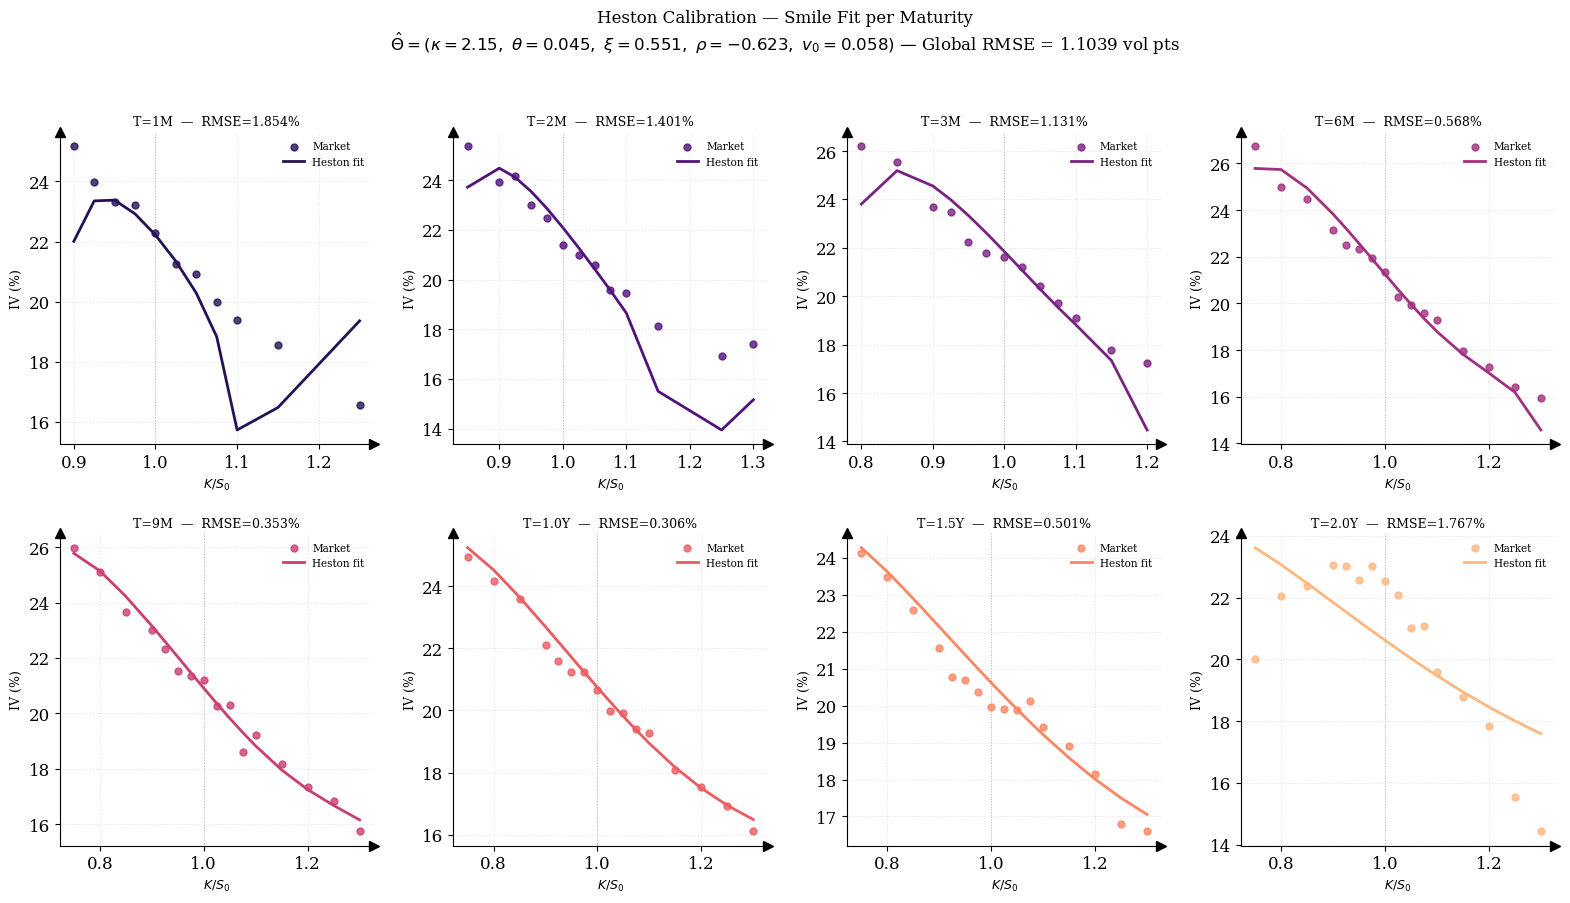

Figure IV.1.2 saved ✓


In [17]:
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes = axes.flatten()

n_mat = min(len(maturities_cal), 8)

for idx in range(n_mat):
    ax  = axes[idx]
    T   = maturities_cal[idx]
    col = cmap(0.15 + 0.7*idx/(n_mat-1) if n_mat > 1 else 0.5)

    iv_mkt = IV_market[idx, :] * 100
    iv_hes = IV_heston[idx, :] * 100
    mask   = ~(np.isnan(iv_mkt) | np.isnan(iv_hes))

    ax.scatter(moneyness_cal[mask], iv_mkt[mask],
               color=col, s=25, zorder=5,
               label='Market', alpha=0.8)
    ax.plot(moneyness_cal[mask], iv_hes[mask],
            color=col, lw=2.0, ls='-',
            label='Heston fit')

    ax.axvline(1.0, color='gray', lw=0.7, ls=':', alpha=0.5)

    lbl_T = (f'T={int(round(T*12))}M' if T < 1
             else f'T={T:.1f}Y')
    rmse_t = rmse_per_mat[idx]
    ax.set_title(f'{lbl_T}  —  RMSE={rmse_t:.3f}%', fontsize=9, pad=5)
    ax.set_xlabel(r'$K/S_0$', fontsize=9)
    ax.set_ylabel('IV (%)', fontsize=9)
    ax.legend(frameon=False, fontsize=7.5, loc='upper right')
    add_arrows(ax)

# Hide unused axes
for idx in range(n_mat, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle(
    f'Heston Calibration — Smile Fit per Maturity\n'
    f'$\\hat{{\\Theta}} = (\\kappa={kappa_cal:.2f},\ \\theta={theta_cal:.3f},\ '
    f'\\xi={xi_cal:.3f},\ \\rho={rho_cal:.3f},\ v_0={v0_cal:.3f})$ — '
    f'Global RMSE = {np.sqrt(np.nanmean(IV_residuals**2)):.4f} vol pts',
    fontsize=12, y=1.01
)
plt.tight_layout(pad=1.5)
plt.savefig('figure_calibration_fit.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figure_calibration_fit.png', bbox_inches='tight', dpi=300)
plt.show()
print('Figure IV.1.2 saved ✓')

### 5.3 Figure — Residuals Map
*(Figure IV.1.3 of the thesis)*

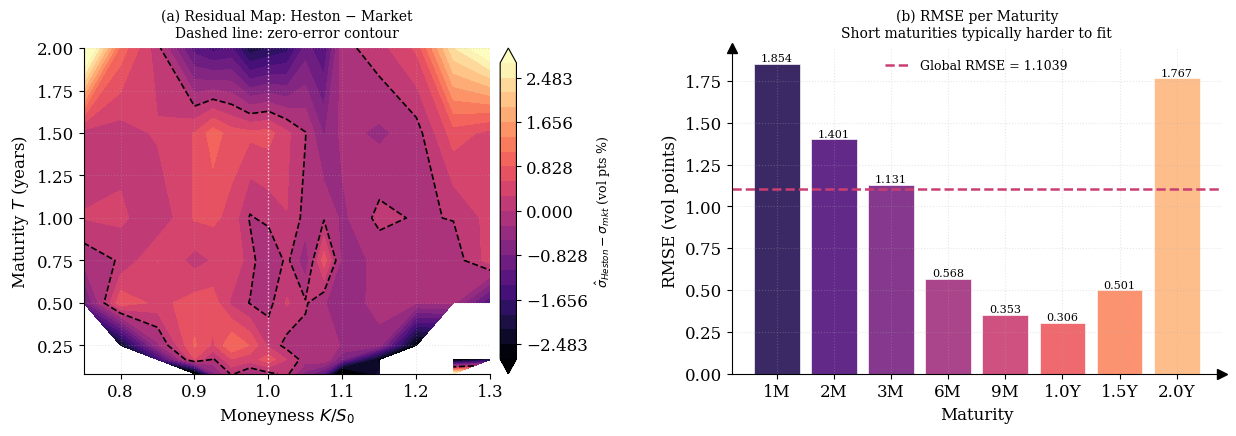

Figure IV.1.3 saved ✓


In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.0))

# ─── Panel (a): Heatmap of residuals in vol points ───────────────────
T_g, M_g = np.meshgrid(maturities_cal, moneyness_cal, indexing='ij')

vmax = np.nanpercentile(np.abs(IV_residuals), 95)
cf = ax1.contourf(M_g, T_g, IV_residuals,
                  levels=np.linspace(-vmax, vmax, 21),
                  cmap='magma', extend='both')
ax1.contour(M_g, T_g, IV_residuals,
            levels=[0], colors='black', linewidths=1.2, linestyles='--')
cbar = plt.colorbar(cf, ax=ax1, pad=0.02)
cbar.set_label(r'$\hat{\sigma}_{Heston} - \sigma_{mkt}$ (vol pts %)',
               fontsize=9)

ax1.axvline(1.0, color='white', lw=1.0, ls=':', alpha=0.7)
ax1.set_xlabel(r'Moneyness $K/S_0$', color=C_TEXT)
ax1.set_ylabel(r'Maturity $T$ (years)', color=C_TEXT)
ax1.set_title('(a) Residual Map: Heston − Market\n'
              r'Dashed line: zero-error contour',
              fontsize=10, pad=8)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ─── Panel (b): RMSE per maturity ───────────────────────────────────
bar_colors = [cmap(0.15 + 0.7*i/(len(maturities_cal)-1))
              if len(maturities_cal) > 1 else cmap(0.5)
              for i in range(len(maturities_cal))]
bar_labels = [(f'{int(round(T*12))}M' if T < 1 else f'{T:.1f}Y')
              for T in maturities_cal]

bars = ax2.bar(bar_labels, rmse_per_mat,
               color=bar_colors, edgecolor='white', linewidth=0.5,
               alpha=0.9)

# Global RMSE line
rmse_global = np.sqrt(np.nanmean(IV_residuals**2))
ax2.axhline(rmse_global, color=cmap(0.55), lw=1.8, ls='--',
            label=f'Global RMSE = {rmse_global:.4f}')

# Annotations on bars
for bar, rmse in zip(bars, rmse_per_mat):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
             f'{rmse:.3f}', ha='center', va='bottom', fontsize=8)

add_arrows(ax2)
ax2.set_xlabel('Maturity', color=C_TEXT)
ax2.set_ylabel('RMSE (vol points)', color=C_TEXT)
ax2.set_title('(b) RMSE per Maturity\n'
              'Short maturities typically harder to fit',
              fontsize=10, pad=8)
ax2.legend(frameon=False, fontsize=9)

plt.tight_layout(pad=2.5)
plt.savefig('figure_residuals.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figure_residuals.png', bbox_inches='tight', dpi=300)
plt.show()
print('Figure IV.1.3 saved ✓')

### 5.4 Figure — 3D Surface Comparison: Market vs Heston
*(Figure IV.1.4 — optional but highly visual for the thesis)*

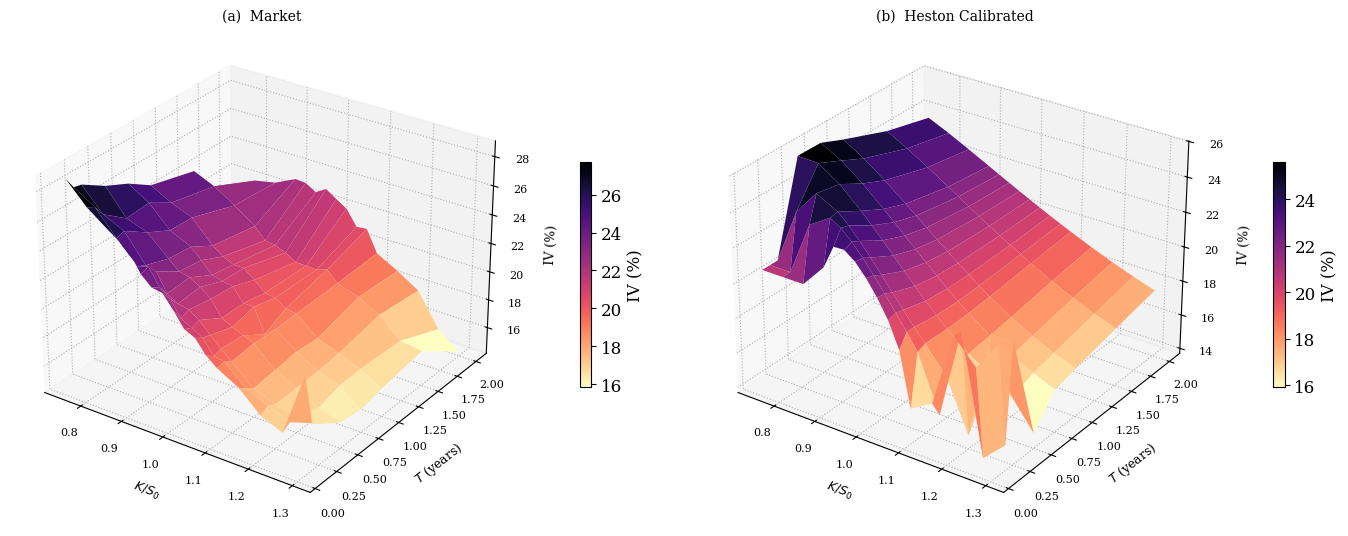

Figure IV.1.4 (3D) saved ✓


In [19]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 6))

for k, (IV_plot, title, alpha_val) in enumerate([
    (IV_market*100, 'Market', 0.65),
    (IV_heston*100, 'Heston Calibrated', 0.65)
]):
    ax = fig.add_subplot(1, 2, k+1, projection='3d')

    T_g, M_g = np.meshgrid(maturities_cal, moneyness_cal, indexing='ij')

    # Mask NaNs (or fill with mean for visualization continuity)
    IV_masked = np.where(np.isnan(IV_plot), np.nanmean(IV_plot), IV_plot)

    surf = ax.plot_surface(
        M_g, T_g, IV_masked,
        cmap='magma_r', alpha=1,
        linewidth=0, antialiased=True
    )

    ax.set_xlabel(r'$K/S_0$', fontsize=9, labelpad=5)
    ax.set_ylabel(r'$T$ (years)', fontsize=9, labelpad=5)
    ax.set_zlabel('IV (%)', fontsize=9, labelpad=5)
    ax.set_title(f'({"ab"[k]})  {title}', fontsize=10, pad=1)
    ax.view_init(elev=28, azim=-55)
    ax.tick_params(labelsize=8)
    fig.colorbar(surf, ax=ax, shrink=0.4, pad=0.1, label='IV (%)')

plt.tight_layout()
plt.savefig('figure_3D_surfaces.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figure_3D_surfaces.png', bbox_inches='tight', dpi=300)
plt.show()
print('Figure IV.1.4 (3D) saved ✓')

---
## 6. Summary Table and Interpretation

### 6.1 Table of Calibrated Parameters

In [20]:
# ── Summary Table ────────────────────────────────────────────────────
feller_ok = 2*kappa_cal*theta_cal > xi_cal**2

table_data = {
    'Parameter':      ['κ (kappa)', 'θ (theta)', 'ξ (xi)', 'ρ (rho)', 'v₀'],
    'Symbol':         [r'$\kappa$', r'$\theta$', r'$\xi$', r'$\rho$', r'$v_0$'],
    'Calibrated':     [f'{kappa_cal:.4f}', f'{theta_cal:.4f}',
                       f'{xi_cal:.4f}',    f'{rho_cal:.4f}', f'{v0_cal:.4f}'],
    'Interpretation': [
        f'Mean-reversion speed  (half-life ≈ {np.log(2)/kappa_cal:.2f}y)',
        f'Long-run variance     (σ_LR = {np.sqrt(theta_cal)*100:.2f}%)',
        f'Vol-of-vol            (smile curvature driver)',
        f'Asset-vol correlation (leverage effect, equity skew)',
        f'Initial variance      (σ_0 = {np.sqrt(v0_cal)*100:.2f}%)'
    ]
}

df_table = pd.DataFrame(table_data)
print('='*80)
print('CALIBRATION RESULTS SUMMARY')
print('='*80)
print(df_table.to_string(index=False))
print('='*80)
print(f'Global RMSE  : {np.sqrt(np.nanmean(IV_residuals**2))*100:.4f} bps')
print(f'Feller check : 2κθ = {2*kappa_cal*theta_cal:.4f}  ξ² = {xi_cal**2:.4f}  '
      f'→ {"SATISFIED ✓" if feller_ok else "VIOLATED ✗"}')

CALIBRATION RESULTS SUMMARY
Parameter   Symbol Calibrated                                       Interpretation
κ (kappa) $\kappa$     2.1539            Mean-reversion speed  (half-life ≈ 0.32y)
θ (theta) $\theta$     0.0448                Long-run variance     (σ_LR = 21.16%)
   ξ (xi)    $\xi$     0.5507       Vol-of-vol            (smile curvature driver)
  ρ (rho)   $\rho$    -0.6229 Asset-vol correlation (leverage effect, equity skew)
       v₀    $v_0$     0.0577                 Initial variance      (σ_0 = 24.02%)
Global RMSE  : 110.3910 bps
Feller check : 2κθ = 0.1928  ξ² = 0.3032  → VIOLATED ✗


In [21]:
# ── LaTeX Table Export ───────────────────────────────────────────────
feller_str = r'$\checkmark$ satisfied' if feller_ok else r'$\times$ violated'

lines = [
    r'\begin{table}[h!]',
    r'\centering',
    r'\begin{tabular}{lccc}',
    r'\toprule',
    r'\textbf{Parameter} & \textbf{Symbol} & \textbf{Calibrated Value} & \textbf{Economic Interpretation} \\',
    r'\midrule',
    r'Mean-reversion speed  & $\kappa$ & %.4f & Half-life $\approx %.2f$ years \\' % (kappa_cal, np.log(2)/kappa_cal),
    r'Long-run variance     & $\theta$ & %.4f & $\sigma_{LR} = %.2f\%%$ \\' % (theta_cal, np.sqrt(theta_cal)*100),
    r'Vol-of-vol            & $\xi$    & %.4f & Smile curvature \\' % xi_cal,
    r'Asset-vol correlation & $\rho$   & %.4f & Leverage effect (negative skew) \\' % rho_cal,
    r'Initial variance      & $v_0$    & %.4f & $\sigma_0 = %.2f\%%$ \\' % (v0_cal, np.sqrt(v0_cal)*100),
    r'\midrule',
    r'\multicolumn{2}{l}{Global RMSE} & \multicolumn{2}{r}{$%.4f$ vol pts} \\' % np.sqrt(np.nanmean(IV_residuals**2)),
    r'\multicolumn{2}{l}{Feller condition $2\kappa\theta > \xi^2$} & \multicolumn{2}{r}{%s} \\' % feller_str,
    r'\bottomrule',
    r'\end{tabular}',
    r'\caption{\textbf{Heston Calibration Results.}',
    r'Calibrated parameters obtained by hybrid Differential Evolution +',
    r'Levenberg-Marquardt optimization on the S\&P~500 implied volatility surface.',
    r'Vega-weighted RMSE criterion.}',
    r'\label{tab:calibration_results}',
    r'\end{table}',
]

latex_table = '\n'.join(lines)
print(latex_table)

with open('table_calibration.tex', 'w') as f:
    f.write(latex_table)
print('\nLaTeX Table saved: table_calibration.tex ✓')

\begin{table}[h!]
\centering
\begin{tabular}{lccc}
\toprule
\textbf{Parameter} & \textbf{Symbol} & \textbf{Calibrated Value} & \textbf{Economic Interpretation} \\
\midrule
Mean-reversion speed  & $\kappa$ & 2.1539 & Half-life $\approx 0.32$ years \\
Long-run variance     & $\theta$ & 0.0448 & $\sigma_{LR} = 21.16\%$ \\
Vol-of-vol            & $\xi$    & 0.5507 & Smile curvature \\
Asset-vol correlation & $\rho$   & -0.6229 & Leverage effect (negative skew) \\
Initial variance      & $v_0$    & 0.0577 & $\sigma_0 = 24.02\%$ \\
\midrule
\multicolumn{2}{l}{Global RMSE} & \multicolumn{2}{r}{$1.1039$ vol pts} \\
\multicolumn{2}{l}{Feller condition $2\kappa\theta > \xi^2$} & \multicolumn{2}{r}{$\times$ violated} \\
\bottomrule
\end{tabular}
\caption{\textbf{Heston Calibration Results.}
Calibrated parameters obtained by hybrid Differential Evolution +
Levenberg-Marquardt optimization on the S\&P~500 implied volatility surface.
Vega-weighted RMSE criterion.}
\label{tab:calibration_results}
\en

### 6.2 Sensitivity Analysis — Parameter Stability

We verify the stability of the calibration by slightly perturbing the market surface (residual bootstrapping).

In [27]:
N_BOOTSTRAP = 30
np.random.seed(0)

bootstrap_results = []
print(f'Stability Bootstrap ({N_BOOTSTRAP} replications)...')

for b_iter in range(N_BOOTSTRAP):
    # Gaussian perturbation ±30bps on the surface
    noise        = np.random.normal(0, 0.003, IV_market.shape)
    IV_perturbed = np.clip(IV_market + noise, 0.05, 1.5)
    IV_perturbed[np.isnan(IV_market)] = np.nan

    # Vectorized residuals via FFT — same logic as objective()
    def residuals_boot(params):
        kappa, theta, xi, rho, v0 = params
        if (kappa <= 0 or theta <= 0 or xi <= 0
                or abs(rho) >= 1 or v0 <= 0):
            return np.full(50, 1e3)
        res = []
        try:
            from scipy.interpolate import interp1d
            for i, T in enumerate(maturities_cal):
                ku, fft_prices = heston_fft_prices(
                    S0, T, r, q, v0, kappa, theta, xi, rho)
                f_i = interp1d(ku, fft_prices, kind='cubic',
                               bounds_error=False, fill_value=np.nan)
                for j, m in enumerate(moneyness_cal):
                    if np.isnan(IV_perturbed[i, j]):
                        continue
                    K     = m * S0
                    price = float(f_i(np.log(K)))
                    iv_h  = implied_vol(price, S0, K, T, r, q)
                    if np.isnan(iv_h):
                        continue
                    res.append(iv_h - IV_perturbed[i, j])
        except Exception:
            return np.full(50, 1e3)
        return np.array(res) if res else np.full(50, 1e3)

    try:
        # Local refinement starting from the calibrated parameters
        res_b = least_squares(
            residuals_boot,
            x0       = params_cal,
            bounds   = (lb, ub),
            method   = 'trf',
            ftol     = 1e-5,
            xtol     = 1e-5,
            max_nfev = 200,
            verbose  = 0
        )
        if res_b.cost < 1e4:   # Reject divergences
            bootstrap_results.append(res_b.x)
    except Exception:
        pass

    if (b_iter + 1) % 10 == 0:
        print(f'  {b_iter+1}/{N_BOOTSTRAP} ✓')

bootstrap_results = np.array(bootstrap_results) if bootstrap_results else np.empty((0, 5))
param_names = ['κ', 'θ', 'ξ', 'ρ', 'v₀']

print(f'\n{len(bootstrap_results)} replications converged out of {N_BOOTSTRAP}')
if bootstrap_results.ndim == 2 and len(bootstrap_results) >= 2:
    stds = bootstrap_results.std(axis=0)
    print('Stability (bootstrap std):')
    for name, std in zip(param_names, stds):
        print(f'  {name}: std = {std:.5f}')
else:
    print('Not enough converged replications to calculate std.')
    stds = np.zeros(5)

Stability Bootstrap (30 replications)...
  10/30 ✓
  20/30 ✓
  30/30 ✓

30 replications converged out of 30
Stability (bootstrap std):
  κ: std = 0.14743
  θ: std = 0.00029
  ξ: std = 0.02312
  ρ: std = 0.00705
  v₀: std = 0.00043


### 6.3 Figure — Bootstrap Parameter Distributions
*(Figure IV.1.5 of the thesis — calibration stability)*

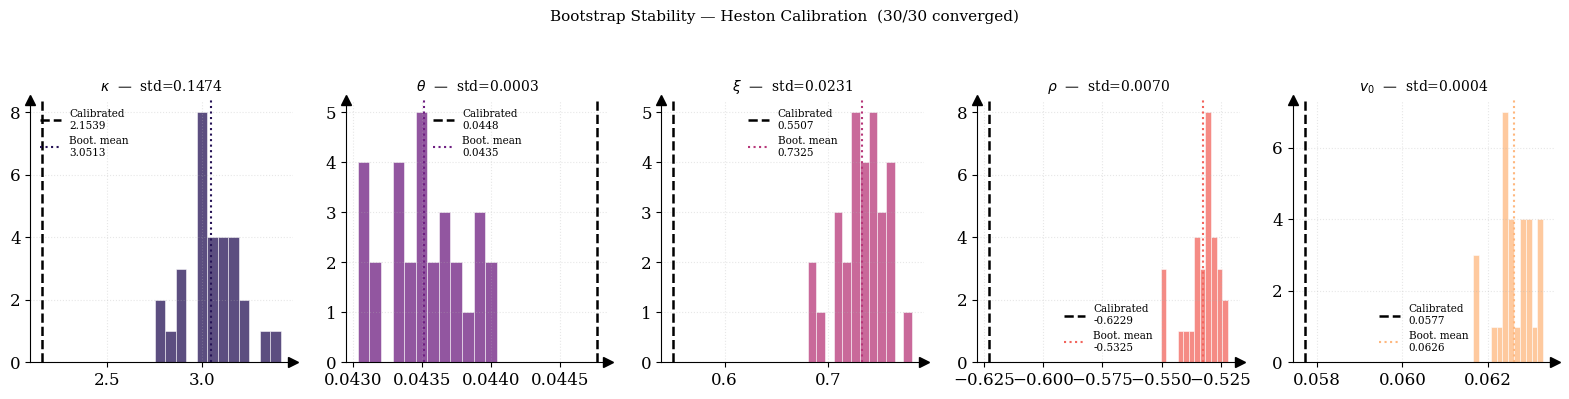

Figure IV.1.5 saved ✓


In [28]:
if bootstrap_results.ndim == 2 and len(bootstrap_results) >= 3:
    fig, axes = plt.subplots(1, 5, figsize=(16, 4.0))
    symbols   = [r'$\kappa$', r'$\theta$', r'$\xi$', r'$\rho$', r'$v_0$']

    for idx, (ax, sym, val) in enumerate(zip(axes, symbols, params_cal)):
        col  = cmap(0.15 + 0.7*idx/4)
        data = bootstrap_results[:, idx]

        ax.hist(data, bins=min(12, len(data)),
                color=col, alpha=0.75,
                edgecolor='white', linewidth=0.5)
        ax.axvline(val, color='black', lw=1.8, ls='--',
                   label=f'Calibrated\n{val:.4f}')
        ax.axvline(np.mean(data), color=col, lw=1.5, ls=':',
                   label=f'Boot. mean\n{np.mean(data):.4f}')

        add_arrows(ax)
        ax.set_title(f'{sym}  —  std={stds[idx]:.4f}',
                     fontsize=10, pad=6)
        ax.legend(frameon=False, fontsize=7.5)

    plt.suptitle(
        f'Bootstrap Stability — Heston Calibration  '
        f'({len(bootstrap_results)}/{N_BOOTSTRAP} converged)',
        fontsize=11, y=1.01
    )
    plt.tight_layout(pad=1.5)
    plt.savefig('figure_bootstrap_stability.pdf', bbox_inches='tight', dpi=300)
    plt.savefig('figure_bootstrap_stability.png', bbox_inches='tight', dpi=300)
    plt.show()
    print('Figure IV.1.5 saved ✓')
else:
    n = len(bootstrap_results) if bootstrap_results.ndim == 2 else 0
    print(f'Only {n} replications converged — figure not plotted.')
    print('Tip: reduce ftol/xtol in the bootstrap or increase max_nfev.')

---
## 7. Exporting Parameters for Subsequent Notebooks

In [29]:
import json

calibration_results = {
    # Calibrated parameters
    'kappa': float(kappa_cal),
    'theta': float(theta_cal),
    'xi':    float(xi_cal),
    'rho':   float(rho_cal),
    'v0':    float(v0_cal),
    # Market data
    'S0':    float(S0),
    'r':     float(r),
    'q':     float(q),
    # Metrics
    'rmse_global': float(np.sqrt(np.nanmean(IV_residuals**2))),
    'feller_ok':   bool(feller_ok),
    # Calibration grid
    'maturities': list(maturities_cal),
    'moneyness':  list(moneyness_cal),
}

with open('heston_calibrated_params.json', 'w') as f:
    json.dump(calibration_results, f, indent=2)

print('Parameters exported → heston_calibrated_params.json ✓')
print()
print('Files generated in this notebook:')
print('  📊 figure_IV_market_surface.pdf   — Observed market surface')
print('  📊 figure_calibration_fit.pdf     — Smile fit by maturity')
print('  📊 figure_residuals.pdf           — Residual map + RMSE')
print('  📊 figure_3D_surfaces.pdf         — 3D surfaces market vs Heston')
print('  📊 figure_bootstrap_stability.pdf — Parameter stability')
print('  📄 table_calibration.tex          — LaTeX parameter table')
print('  💾 heston_calibrated_params.json  — Parameters for notebooks 02/03')

Parameters exported → heston_calibrated_params.json ✓

Files generated in this notebook:
  📊 figure_IV_market_surface.pdf   — Observed market surface
  📊 figure_calibration_fit.pdf     — Smile fit by maturity
  📊 figure_residuals.pdf           — Residual map + RMSE
  📊 figure_3D_surfaces.pdf         — 3D surfaces market vs Heston
  📊 figure_bootstrap_stability.pdf — Parameter stability
  📄 table_calibration.tex          — LaTeX parameter table
  💾 heston_calibrated_params.json  — Parameters for notebooks 02/03
